# Training of a WGAN on disk images.

In [1]:
import functools as ft
import os
from collections.abc import Iterable, Iterator
from pathlib import Path
from typing import Any, Protocol

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import optax
import scienceplots  # noqa: F401
from jaxtyping import PyTree
from mpl_toolkits.axes_grid1 import make_axes_locatable

from organic.training_data import TrainingImgLoader
from organic.utils import _create_output_dir

# Set matplotlib settings

In [2]:
# set scienceplots style and matplotlib settings
plt.style.use(["science", "bright", "no-latex"])

new_rcParams = {
    "image.cmap": "inferno",
    "font.family": "serif",
    "figure.dpi": 300,
    "font.size": 8,
    "xtick.direction": "out",
    "ytick.direction": "out",
}
plt.rcParams.update(new_rcParams)

## Defining a protocol for the generator and critic's call-sign

In [ ]:
class WGANComponent(Protocol, PyTree):
    """Protocol defining the call signature that ORGANIC expects for a WGAN generator
    or critic component. Specifically, ORGANIC expects a registered PyTree with the
    following call signature: `__call__(self, x: jax.Array, state: eqx.nn.State, *,
    key: jax.Array) -> tuple[jax.Array, eqx.nn.State]`. This does not mean that
    components must actually implement stateful or stochastic layers (via the `key`
    argument), but the `state` and `key` arguments must be present for general API
    compatibility with ORGANIC's internals. This means that any kind of PyTree passed
    to ORGANIC's API must be initialized via `equinox.nn.make_with_state` (this works
    even if the PyTree does not inherit from `equinox.Module`).
    """

    def __call__(
        self, x: jax.Array, state: eqx.nn.State, *, key: jax.Array
    ) -> tuple[jax.Array, eqx.nn.State]: ...

## Defining generator and critic class

In [ ]:
class GeneratorDisksNIROld(eqx.Module):
    """WGAN generator for monochromatic NIR disk images.

    **Attributes**

    - `layers`: Tuple containing the different neural network layers. The only
        requirement is that each layer should just be callable using the output of the
        preceding layer. The first layer needs to be able to accept a latent 'noise'
        vector of size `size_in`.
    - `size_in`: Size of the latent 'noise' input vector to the first layer.
    """

    layers: tuple[Any, ...]  # Different callable layers.
    size_in: int = eqx.field(static=True)  # Size of input latent vector.

    def __init__(self, key: jax.Array) -> None:
        """**Arguments**

        - `key`: JAX PRNG key to initialise the model.
        """
        key, subkey1, subkey2, subkey3, subkey4, subkey5 = jr.split(key, 6)

        self.size_in = 100
        self.layers = (
            eqx.nn.Linear(
                100, 256 * 16 * 16, use_bias=True, key=subkey1
            ),  # Fully connected.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.Lambda(
                lambda x: jnp.reshape(x, shape=(256, 16, 16))
            ),  # Reshape to 256 x 16 x 16.
            eqx.nn.ConvTranspose2d(
                in_channels=256,
                out_channels=128,
                kernel_size=(4, 4),
                stride=(2, 2),
                padding="SAME",
                padding_mode="ZEROS",
                use_bias=True,
                key=subkey2,
            ),  # Transposed convolution to 128 x 32 x 32.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.ConvTranspose2d(
                in_channels=128,
                out_channels=64,
                kernel_size=(4, 4),
                stride=(2, 2),
                padding="SAME",
                padding_mode="ZEROS",
                use_bias=True,
                key=subkey3,
            ),  # Transposed convolution to 64 x 64 x 64.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.ConvTranspose2d(
                in_channels=64,
                out_channels=32,
                kernel_size=(4, 4),
                stride=(2, 2),
                padding="SAME",
                padding_mode="ZEROS",
                use_bias=True,
                key=subkey4,
            ),  # Transposed convolution to 32 x 128 x 128.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.Conv2d(
                in_channels=32,
                out_channels=1,
                kernel_size=(5, 5),
                stride=(1, 1),
                padding="SAME",
                padding_mode="ZEROS",
                use_bias=True,
                key=subkey5,
            ),  # Final regular convolution to 1 x 128 x 128.
            eqx.nn.Lambda(
                lambda x: jnp.tanh(x)
            ),  # Final activation to map to signed unit interval [-1, 1].
        )
        return

    def __call__(
        self, x: jax.Array, state: eqx.nn.State, *, key: jax.Array
    ) -> tuple[jax.Array, eqx.nn.State]:
        """Feed-forward pass through the generator neural network.

        **Arguments**

        - `x`: 1D input vector.

        - `state`: The current state of the generator.

        - `key`: A JAX PRNG key meant for calling stochastic layers.

        **Returns**

        A 3D image (Y, X, Channel indexing) cube as a JAX array and the updated
        state of the generator.
        """
        # print(f"SHAPE OF INPUT X: {x.shape}")
        for layer in self.layers:
            # print(f"CURRENTLY CONSIDERING LAYER OF TYPE '{type(layer)}'")
            if isinstance(layer, eqx.nn.StatefulLayer):
                x, state = layer(x, state)
            else:
                x = layer(x)
            # print(f"OUTPUT SHAPE: {x.shape}")
        return x, state


class GeneratorDisksNIR(eqx.Module):
    """WGAN generator for monochromatic NIR disk images with upsampling.

    **Attributes**

    - `layers`: Tuple containing the different neural network layers. The only
        requirement is that each layer should just be callable using the output of the
        preceding layer, producing a 3D image (Y, X, Channel indexing) cube from an
        input 1D latent vector of given `size_in`.
    - `size_in`: Size of the latent 'noise' input vector to the first layer.
    """

    layers: tuple[Any, ...]  # Different callable layers.
    size_in: int = eqx.field(static=True)  # Size of input latent vector.

    def __init__(self, key: jax.Array) -> None:
        """**Arguments**

        - `key`: JAX PRNG key to initialise the model.
        """
        key, subkey1, subkey2, subkey3, subkey4, subkey5 = jr.split(key, 6)

        self.size_in = 100
        self.layers = (
            eqx.nn.Linear(
                self.size_in, 256 * 16 * 16, use_bias=True, key=subkey1
            ),  # Fully connected from shape (100,) to (256 * 16 * 16,).
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.Lambda(
                lambda x: jnp.reshape(x, shape=(256, 16, 16))
            ),  # Reshape to 256 x 16 x 16.
            eqx.nn.Lambda(
                lambda x: jnp.repeat(
                    jnp.repeat(x, repeats=2, axis=1),
                    2,
                    axis=2,
                )
            ),  # Upsample to 256 x 32 x 32.
            eqx.nn.Conv2d(
                in_channels=256,
                out_channels=128,
                kernel_size=(3, 3),
                stride=(1, 1),
                padding="SAME",
                padding_mode="ZEROS",
                use_bias=True,
                key=subkey2,
            ),  # Regular convolution to 128 x 32 x 32.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.Lambda(
                lambda x: jnp.repeat(
                    jnp.repeat(x, repeats=2, axis=1),
                    2,
                    axis=2,
                )
            ),  # Upsample to 128 x 64 x 64.
            eqx.nn.Conv2d(
                in_channels=128,
                out_channels=64,
                kernel_size=(3, 3),
                stride=(1, 1),
                padding="SAME",
                padding_mode="ZEROS",
                use_bias=True,
                key=subkey3,
            ),  # Regular convolution to 64 x 64 x 64.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.Lambda(
                lambda x: jnp.repeat(
                    jnp.repeat(x, repeats=2, axis=1),
                    repeats=2,
                    axis=2,
                )
            ),  # Upsample to 64 x 128 x 128.
            eqx.nn.Conv2d(
                in_channels=64,
                out_channels=32,
                kernel_size=(3, 3),
                stride=(1, 1),
                padding="SAME",
                padding_mode="ZEROS",
                use_bias=True,
                key=subkey4,
            ),  # Regular convolution to 32 x 128 x 128.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.Conv2d(
                in_channels=32,
                out_channels=1,
                kernel_size=(5, 5),
                stride=(1, 1),
                padding="SAME",
                padding_mode="ZEROS",
                use_bias=True,
                key=subkey5,
            ),  # Final regular convolution to 1 x 128 x 128.
            eqx.nn.Lambda(
                lambda x: jnp.tanh(x)
            ),  # Final activation to map to signed unit interval [-1, 1].
        )
        return

    def __call__(
        self, x: jax.Array, state: eqx.nn.State, *, key: jax.Array
    ) -> tuple[jax.Array, eqx.nn.State]:
        """Feed-forward pass through the generator neural network.

        **Arguments**

        - `x`: 1D input vector.

        - `state`: The current state of the generator.

        - `key`: A JAX PRNG key meant for calling stochastic layers.

        **Returns**

        A 3D image (Y, X, Channel indexing) cube as a JAX array and the updated
        state of the generator.
        """
        # print(f"SHAPE OF INPUT X: {x.shape}")
        for layer in self.layers:
            # print(f"CURRENTLY CONSIDERING LAYER OF TYPE '{type(layer)}'")
            if isinstance(layer, eqx.nn.StatefulLayer):
                x, state = layer(x, state)
            else:
                x = layer(x)
            # print(f"OUTPUT SHAPE: {x.shape}")
        return x, state


class CriticDisksNIR(eqx.Module):
    """WGAN critic for monochromatic NIR disk images. Spectrally normalized to
    maintain 1-Lipschitz continuity.

    **Attributes**

    - `layers`: Tuple containing the different neural network layers. The only
        requirement is that each layer should just be callable using the output of the
        preceding layer. The first layer needs to be able to accept a 3D image (Y, X,
        Channel indexing) cube.
    """

    layers: tuple[Any, ...]  # Different callable layers.

    def __init__(self, key: jax.Array) -> None:
        """**Arguments**

        - `key`: JAX PRNG key to initialise the model.
        """
        (
            key,
            subkey1,
            subkey2,
            subkey3,
            subkey4,
            subkey5,
            subkey6,
            subkey7,
            subkey8,
        ) = jr.split(key, 9)

        self.layers = (
            eqx.nn.SpectralNorm(
                eqx.nn.Conv2d(
                    in_channels=1,
                    out_channels=32,
                    kernel_size=(5, 5),
                    stride=(2, 2),
                    padding="SAME",
                    padding_mode="ZEROS",
                    use_bias=True,
                    key=subkey1,
                ),
                weight_name="weight",
                num_power_iterations=4,
                key=subkey2,
            ),  # Regular convolution to 32 x 64 x 64 (assuming input is 1 x 128 x 128).
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.25)
            ),  # Activation.
            eqx.nn.SpectralNorm(
                eqx.nn.Conv2d(
                    in_channels=32,
                    out_channels=64,
                    kernel_size=(3, 3),
                    stride=(2, 2),
                    padding="SAME",
                    padding_mode="ZEROS",
                    use_bias=True,
                    key=subkey3,
                ),
                weight_name="weight",
                num_power_iterations=4,
                key=subkey4,
            ),  # Regular convolution to 64 x 32 x 32.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.25)
            ),  # Activation.
            eqx.nn.SpectralNorm(
                eqx.nn.Conv2d(
                    in_channels=64,
                    out_channels=128,
                    kernel_size=(3, 3),
                    stride=(2, 2),
                    padding="SAME",
                    padding_mode="ZEROS",
                    use_bias=True,
                    key=subkey5,
                ),
                weight_name="weight",
                num_power_iterations=4,
                key=subkey6,
            ),  # Regular convolution to 128 x 16 x 16.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.25)
            ),  # Activation.
            eqx.nn.Lambda(lambda x: jnp.ravel(x)),  # Ravel to shape (128 * 16 * 16,)
            eqx.nn.SpectralNorm(
                eqx.nn.Linear(128 * 16 * 16, 1, use_bias=True, key=subkey7),
                weight_name="weight",
                num_power_iterations=4,
                key=subkey8,
            ),  # Final activation to scalar of shape (1,)
        )

        return

    def __call__(
        self, x: jax.Array, state: eqx.nn.State, *, key: jax.Array
    ) -> tuple[jax.Array, eqx.nn.State]:
        """Feed-forward pass through the neural network.

        **Arguments**

        - `x`: A 3D image (Y, X, Channel indexing) cube array.

        - `state`: The current state of the critic.

        - `key`: A JAX PRNG key meant for calling stochastic layers.

        **Returns**

        A shape (1,) scalar meant to represent the WGAN critic output and the updated
        state of the critic.
        """
        # print("\n")
        # print(f"SHAPE OF INPUT X: {x.shape}")
        for layer in self.layers:
            # print(f"CURRENTLY CONSIDERING LAYER OF TYPE '{type(layer)}'")
            if isinstance(layer, eqx.nn.StatefulLayer):
                x, state = layer(x, state)
            else:
                x = layer(x)
            # print(f"OUTPUT SHAPE: {x.shape}")
        return x, state

State() State()
State() State()


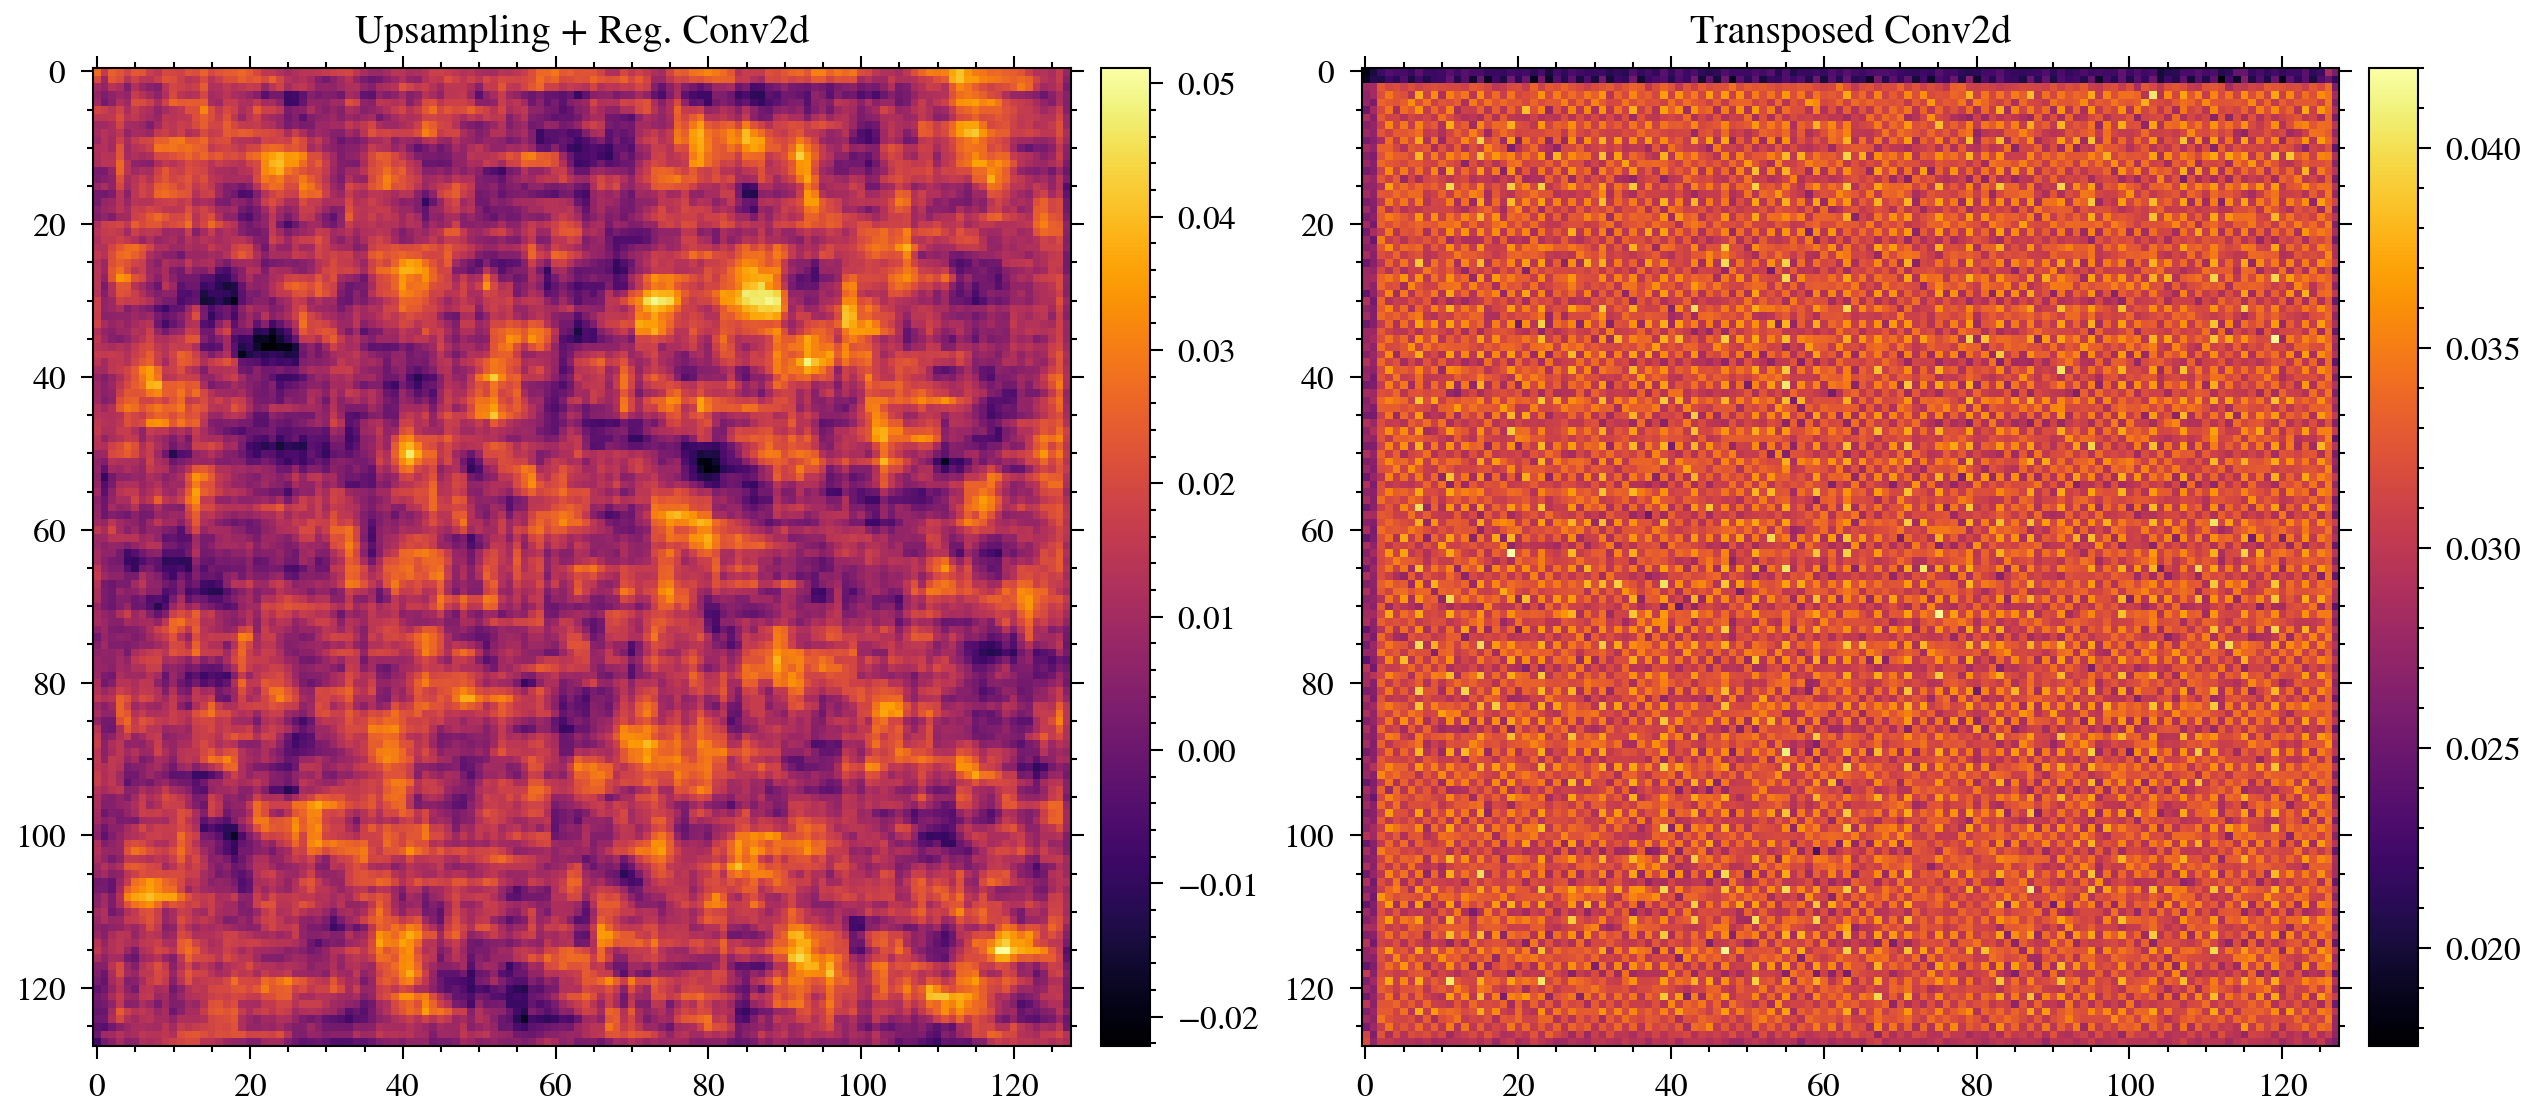

In [ ]:
key = jr.key(42)
key, subkey1, subkey2, subkey3, subkey4, subkey5 = jr.split(key, 6)

gen_notrans, gen_notrans_state = eqx.nn.make_with_state(GeneratorDisksNIR)(key=subkey1)
gen_trans, gen_trans_state = eqx.nn.make_with_state(GeneratorDisksNIROld)(key=subkey2)

print(gen_notrans_state, gen_trans_state)

z_test = jr.normal(key=subkey3, shape=(100,))
test_pass_notrans, gen_notrans_state = gen_notrans(
    z_test, gen_notrans_state, key=subkey4
)
test_pass_trans, gen_trans_state = gen_trans(z_test, gen_trans_state, key=subkey5)

print(gen_notrans_state, gen_trans_state)

fig, ax = plt.subplots(1, 2, figsize=(10, 10))
im = ax[0].imshow(test_pass_notrans[0, :, :])
divider = make_axes_locatable(ax[0])
cax = divider.append_axes("right", size="5%", pad=0.1)  # <-- key controls
fig.colorbar(im, cax=cax)
ax[0].set_title("Upsampling + Reg. Conv2d")
im = ax[1].imshow(test_pass_trans[0, :, :])
divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="5%", pad=0.1)  # <-- key controls
fig.colorbar(im, cax=cax)
ax[1].set_title("Transposed Conv2d")
plt.show()

In [ ]:
key, subkey1, subkey2, subkey3, subkey4 = jr.split(key, 5)
crit, crit_state = eqx.nn.make_with_state(CriticDisksNIR)(key=subkey1)

print(crit_state)

key, subkey = jr.split(subkey2, 2)
img_test = jr.normal(key=subkey3, shape=(1, 128, 128))

w_test = crit(img_test, crit_state, key=subkey4)

State(
  CriticDisksNIR.layers[0].uv_index=(f32[32], f32[25]),
  CriticDisksNIR.layers[2].uv_index=(f32[64], f32[288]),
  CriticDisksNIR.layers[4].uv_index=(f32[128], f32[576]),
  CriticDisksNIR.layers[7].uv_index=(f32[1], f32[32768])
)




### Auxiliary function definitions

#### Loss functions

In [ ]:
def _wgan_gen_loss(
    gen_params: WGANComponent,
    gen_static: WGANComponent,
    gen_state: eqx.nn.State,
    crit_params: WGANComponent,
    crit_static: WGANComponent,
    crit_state: eqx.nn.State,
    z_in: jax.Array,
    *,
    key: jax.Array,
) -> tuple[jax.Array, tuple[eqx.nn.State, eqx.nn.State]]:
    """Get the generator's loss value evaluated on a batch of random 1D latent input
    vectors.

    **Arguments**

    - `gen_params`: The generator's trainable parameters. This should generally only
        include components that return `True` under `eqx.is_array`.
    - `gen_static`: The generator's non-trainable components. This should generally only
        include components that return `False` under `eqx.is_array`.
    - `gen_state`: The generator's state. An updated generator state is returned
        after evaluating the batch.
    - `crit_params`: The critic's trainable parameters. This should generally only
        include components that return `True` under `eqx.is_array`.
    - `crit_static`: The critic's non-trainable components. This should generally only
        include components that return `False` under `eqx.is_array`.
    - `crit_state`: The critic's state. Note that the critic's state should not be
        updated in any way meaningful way, since the critic should be in inference mode
        (see the warning below). It is still returned for API compatibility.
    - `z_in`: The batch of 1D generator random latent input vectors. The first index
        should run over the different batch elements, the second over the vectors
        themselves.
    - `key`: JAX PRNG key for calling stochastic layers.

    **Returns**

    Returns a tuple `(gen_loss, (gen_state, crit_state))`, where `gen_loss` is the
    WGAN generator loss over the batch. The state of the generator and critic are also
    returned as auxiliary data. Note that this loss is value is not fully equivalent
    to the actual Wasserstein distance, since the parts of the WGAN Wasserstein estimate
    that are dependent on the training distribution (which do not contribute to the
    gradients of the Wasserstein distance w.r.t. the generator) are dropped.

    !!! warning

    Note that the critic should be set in inference mode before calling this function.
    Since this function is meant to be used in a JAX JIT-ed update step of the
    generator, it implements no way of checking or enforcing this, and trusts the
    caller made sure of this beforehand.
    """
    # Combine params and static into full models again.
    gen = eqx.combine(gen_params, gen_static)
    crit = eqx.combine(crit_params, crit_static)

    # Generate PRNG keys for possible stochastic layers in model calls.
    key, subkeys_gen_batch = jr.split(key, z_in.shape[0] + 1)
    key, subkeys_crit_batch = jr.split(key, z_in.shape[0] + 1)

    # Generate batch of images from the generator. Note that JAX automatically considers
    # input keywords to be batched over axis 0. This means we need to provide a 1D batch
    # of PRNG `key` arguments. This means every image resulting from this batch will
    # be calculated using different randomization for the stochastic layers. The
    # optional axis name "batch" is provided as an assumed standard in ORGANIC when
    # layers need access to the batch dimension for parallel computations (e.g.
    # `equinox.nn.BatchNorm`).
    gen_img_batch, gen_state = jax.vmap(
        gen, in_axes=(0, None), out_axes=(0, None), axis_name="batch"
    )(z_in, gen_state, key=subkeys_gen_batch)

    # Compute critic estimates for batch. Note that the critic is assumed
    # to be in inference mode. The same comments regarding `jax.vmap` as above apply.
    y_est_batch, crit_state = jax.vmap(
        crit, in_axes=(0, None), out_axes=(0, None), axis_name="batch"
    )(gen_img_batch, crit_state, key=subkeys_crit_batch)

    # Compute the final scalar loss over the generator image batch.
    gen_loss = -jnp.mean(y_est_batch)

    # Return loss and updated states of generator and critic.
    return gen_loss, (gen_state, crit_state)


@ft.partial(
    jax.jit,
    static_argnames=("gen_static", "crit_static", "opt_gen", "size_in", "batch_size"),
)
def _wgan_gen_make_step(
    gen_params: WGANComponent,
    gen_static: WGANComponent,
    gen_state: eqx.nn.State,
    crit_params: WGANComponent,
    crit_static: WGANComponent,
    crit_state: eqx.nn.State,
    opt_gen: optax.GradientTransformation,
    opt_gen_state: optax.OptState,
    *,
    key: jax.Array,
    size_in: int,
    batch_size: int,
) -> tuple[WGANComponent, eqx.nn.State, eqx.nn.State, optax.OptState, jax.Array]:
    """Function that performs a training step for the generator during WGAN training by
    minimizing the corresponding loss function.

    **Arguments**

    - `gen_params`: The generator's trainable parameters. This should generally only
        include components that return `True` under `eqx.is_array`.
    - `gen_static`: The generator's non-trainable components. This should generally only
        include components that return `False` under `eqx.is_array`. Note that this
        argument is supposed to be set to training mode.
    - `gen_state`: The generator's current state. An updated generator state is returned
        after evaluating the batch.
    - `crit_params`: The critic's trainable parameters. This should generally only
        include components that return `True` under `eqx.is_array`.
    - `crit_static`: The critic's non-trainable components. This should generally only
        include components that return `False` under `eqx.is_array`. Note that this
        argument is supposed to be set to inference mode.
    - `crit_state`: The critic's state (i.e. current status for stateful layers). This
        is included since e.g. spectral normalization enforces Lipschitz-continuity
        in the critic. This state is returned again for API compatibility, but should
        not be meaningfully updated since the critic is assumed to be in inference mode
        (see warning below).
    - `opt_gen`: Optax optimizer used for the generator updates.
    - `opt_gen_state`: Current state of the generator's Optax optimizer.
    - `key`: JAX PRNG key used to generate a batch of 1D generator random latent input
        vectors. Also used to provide randomness to possible stochastic layers.
    - `size_in`: Size of the 1D generator input vectors.
    - `batch_size`: The size of batch to use.

    **Returns**

    The updated generator parameters in `gen_params`, the updated generator state in
    `gen_state`, the critic state in `crit_state` (should not have been updated,
    see warning below), the updated generator optimizer state in `opt_gen_state` and
    the calculated loss value in `gen_loss`.

    !!! warning

    Note that the critic should be set in inference mode before calling this function.
    Its state should not be updated. Since this function is meant to be used in a JAX
    JIT-ed update step of the generator, it implements no way of checking or enforcing
    this, and trusts the caller made sure of this beforehand.
    """
    # Generate a batch of random latent input vectors for the generator. The first index
    # of the batched vectors will run over the different vectors.
    key, subkey1, subkey2 = jr.split(key, 3)
    z_in = jr.normal(key=subkey1, shape=(batch_size, size_in))

    # Get loss estimate and corresponding gradients (which are also estimated gradients
    # relative to the Wasserstein distance; though note the loss value returned here is
    # not exactly the Wasserstein distance since the part that's dependent on the
    # training distribution and the critic's parameters has been dropped) for the
    # generator parameters.
    (gen_loss, (gen_state, crit_state)), gen_params_grads = jax.value_and_grad(
        _wgan_gen_loss,
        argnums=0,
        has_aux=True,
    )(
        gen_params,
        gen_static,
        gen_state,
        crit_params,
        crit_static,
        crit_state,
        z_in,
        key=subkey2,
    )

    # Calculate generator parameter updates and new optimizer state.
    gen_params_updates, opt_gen_state = opt_gen.update(
        gen_params_grads, opt_gen_state, gen_params
    )
    # Apply generator parameter updates.
    gen_params = eqx.apply_updates(gen_params, gen_params_updates)

    return gen_params, gen_state, crit_state, opt_gen_state, gen_loss


def _wgan_crit_loss(
    crit_params: WGANComponent,
    crit_static: WGANComponent,
    crit_state: eqx.nn.State,
    gen_params: WGANComponent,
    gen_static: WGANComponent,
    gen_state: eqx.nn.State,
    training_img_batch: jax.Array,
    z_in: jax.Array,
    *,
    key: jax.Array,
) -> tuple[jax.Array, tuple[eqx.nn.State, eqx.nn.State]]:
    """Get the critic's loss value on a batch of random 1D latent input vectors for
    the generator and a batch of random images from the training set.

    **Arguments**

    - `crit_params`: The critic's trainable parameters. This should generally only
        include components that return `True` under `eqx.is_array`.
    - `crit_static`: The critic's non-trainable components. This should generally only
        include components that return `False` under `eqx.is_array`.
    - `crit_state`: The critic's state. An updated critic state is returned after
        evaluating the batch.
    - `gen_params`: The generator's trainable parameters. This should generally only
        include components that return `True` under `eqx.is_array`.
    - `gen_static`: The generator's non-trainable components. This should generally only
        include components that return `False` under `eqx.is_array`.
    - `gen_state`: The generator's state. Note that the generator's state should not be
        updated in any way meaningful way, since the generator should be in inference
        mode (see the warning below). It is still returned for API compatibility.
    - `training_img_batch`: A batch of training data images. This should be a 4D JAX
        array following (Batch, Channel, Y, X) array indexing.
    - `z_in`: The batch of 1D generator random latent input vectors. The first index
        should run over the different batch elements, the second over the vectors
        themselves.
    - `key`: JAX PRNG key for calling stochastic layers.

    **Returns**

    Returns a tuple `(crit_loss, (crit_state, gen_state))`, where `crit_loss` is the
    WGAN critic loss over the batch. The state of the critic and generator are also
    returned as auxiliary data. If trained to optimality, the returned loss value
    becomes an estimate for the Wasserstein distance between the generated images
    and the distribution of the training data.

    !!! warning

    Note that the generator should be set in inference mode before calling this
    function. Since this function is meant to be used in a JAX JIT-ed update step of the
    critic, it implements no way of checking or enforcing this, and trusts the
    caller made sure of this beforehand.
    """
    # Combine params and static into full models again.
    gen = eqx.combine(gen_params, gen_static)
    crit = eqx.combine(crit_params, crit_static)

    # Generate PRNG keys for possible stochastic layers in model calls.
    key, subkeys_gen_batch = jr.split(key, z_in.shape[0] + 1)
    key, subkeys_crit_batch1 = jr.split(key, z_in.shape[0] + 1)
    key, subkeys_crit_batch2 = jr.split(key, z_in.shape[0] + 1)

    # Generate batch of images from the generator. Note that JAX automatically considers
    # input keywords to be batched over axis 0. This means we need to provide a 1D batch
    # of PRNG `key` arguments. This means every image resulting from this batch will
    # be calculated using different randomization for the stochastic layers. The
    # optional axis name "batch" is provided as an assumed standard in ORGANIC when
    # layers need access to the batch dimension for parallel computations (e.g.
    # `equinox.nn.BatchNorm`). Note that the generator is assumed to be in inference
    # mode.
    gen_img_batch, gen_state = jax.vmap(
        gen, in_axes=(0, None), out_axes=(0, None), axis_name="batch"
    )(z_in, gen_state, key=subkeys_gen_batch)

    # Compute critic estimates for generated image batch. The same comments regarding
    # `jax.vmap` as above apply.
    y_est_gen_batch, crit_state = jax.vmap(
        crit, in_axes=(0, None), out_axes=(0, None), axis_name="batch"
    )(gen_img_batch, crit_state, key=subkeys_crit_batch1)

    # Compute critic estimates for the training image batch. The same comments regarding
    # `jax.vmap` as above apply.
    y_est_crit_batch, crit_state = jax.vmap(
        crit, in_axes=(0, None), out_axes=(0, None), axis_name="batch"
    )(training_img_batch, crit_state, key=subkeys_crit_batch2)

    # Compute the final scalar loss over the generator and training image batches.
    crit_loss = -(jnp.mean(y_est_crit_batch) - jnp.mean(y_est_gen_batch))

    # Return loss and updated states of critic and generator.
    return crit_loss, (crit_state, gen_state)


# Note that the returned state is discarded here as
# the critic state should be only updated further on. Specifically, we don't want
# the power iteration to already have updated the hidden state uv-vectors before
# doing the calculation on of the critic output for the training images.


@ft.partial(
    jax.jit,
    static_argnames=("crit_static", "gen_static", "opt_crit", "size_in", "batch_size"),
)
def _wgan_crit_make_step(
    crit_params: WGANComponent,
    crit_static: WGANComponent,
    crit_state: eqx.nn.State,
    gen_params: WGANComponent,
    gen_static: WGANComponent,
    gen_state: eqx.nn.State,
    opt_crit: optax.GradientTransformation,
    opt_crit_state: optax.OptState,
    *,
    key: jax.Array,
    size_in: int,
    batch_size: int,
    training_img_batch: jax.Array,
) -> tuple[WGANComponent, eqx.nn.State, eqx.nn.State, optax.OptState, jax.Array]:
    """Function that performs a training step for the critic during WGAN training by
    minimizing the corresponding loss function.

    **Arguments**

    - `crit_params`: The critic's trainable parameters. This should generally only
        include components that return `True` under `eqx.is_array`.
    - `crit_static`: The critic's non-trainable components. This should generally only
        include components that return `False` under `eqx.is_array`.
    - `crit_state`: The critic's state. An updated critic state is returned after
        evaluating the batch.
    - `gen_params`: The generator's trainable parameters. This should generally only
        include components that return `True` under `eqx.is_array`.
    - `gen_static`: The generator's non-trainable components. This should generally only
        include components that return `False` under `eqx.is_array`.
    - `gen_state`: The generator's state. Note that the generator's state should not be
        updated in any way meaningful way, since the generator should be in inference
        mode (see the warning below). It is still returned for API compatibility.
    - `opt_crit`: Optax optimizer used for the critic updates.
    - `opt_crit_state`: Current state of the critic's Optax optimizer.
    - `key`: JAX PRNG key used to generate a batch of 1D generator random latent input
        vectors. Also used to provide randomness to possible stochastic layers.
    - `size_in`: Size of the 1D generator input vectors.
    - `batch_size`: The size of batch to use.
    - `training_img_batch`: A batch of training data images. This should be a 4D JAX
       array following (Batch, Channel, Y, X) array indexing. Note that we have to pass
       a pre-generated batch of training images since currently data augmentation
       with e.g. Albumentations is still performed on the host. This makes the API
       slightly different than e.g. `_wgan_gen_make_step()`.

    **Returns**

    The updated critic parameters in `crit_params`, the updated critic state in
    `crit_state`, the generator state in `gen_state` (should not have been updated,
    see warning below), the updated critic optimizer state in `opt_crit_state` and
    the calculated loss value (i.e. the WGAN Wasserstein distance estimate) in
    `crit_loss`.

    !!! warning

    Note that the generator should be set in inference mode before calling this
    function. Its state should not be updated. Since this function is meant to be used
    in a JAX JIT-ed update step of the critic, it implements no way of checking or
    enforcing this, and trusts the caller made sure of this.
    """
    # Generate a batch of random latent input vectors for the generator. The first index
    # of the batched vectors will run over the different vectors.
    key, subkey1, subkey2 = jr.split(key, 3)
    z_in = jr.normal(key=subkey1, shape=(batch_size, size_in))

    # Get loss estimate (corresponding to the Wasserstein estimate if trained to
    # optimality) and corresponding gradients for the critic parameters.
    (crit_loss, (crit_state, gen_state)), crit_params_grads = jax.value_and_grad(
        _wgan_crit_loss,
        argnums=0,
        has_aux=True,
    )(
        crit_params,
        crit_static,
        crit_state,
        gen_params,
        gen_static,
        gen_state,
        training_img_batch,
        z_in,
        key=subkey2,
    )

    # Calculate critic parameter updates and new optimizer state.
    crit_params_updates, opt_crit_state = opt_crit.update(
        crit_params_grads, opt_crit_state, crit_params
    )
    # Apply critic parameter updates.
    crit_params = eqx.apply_updates(crit_params, crit_params_updates)

    return crit_params, crit_state, gen_state, opt_crit_state, crit_loss

#### Shape checking of components before training

In [8]:
def _wgan_check_gen_and_crit(
    gen: WGANComponent,
    gen_state: eqx.nn.State,
    crit: WGANComponent,
    crit_state: eqx.nn.State,
    *,
    size_in: int,
    key: jax.Array,
) -> None:
    """Check the shape compatibility of the generator and critic.

    **Arguments**

    - `gen`: The WGAN generator. This should be a callable PyTree that produces either
         a 3D image (Y, X, Channel indexing) cube from an input 1D latent vector.
    - `gen_state`: Current state of the generator.
    - `crit`: The WGAN critic. This should be a callable PyTree that produces a scalar
        from a 3D image (Y, X, Channel indexing) cube.
    - `crit_state`: Current state of the critic.
    - `size_in`: Size of 1D generator input latent vector.
    - `key`: JAX PRNG key used to generate a generator latent random input vector for
        testing.
    """
    key, subkey1, subkey2, subkey3 = jr.split(key, 4)
    z_test = jr.normal(key=subkey1, shape=(size_in,))
    img_gen_test, _ = gen(z_test, gen_state, key=subkey2)
    if img_gen_test.ndim != 3:
        raise ValueError(
            "Generator should produce 3D image cubes using "
            "(Channel, Y, X) indexing. Instead found a generator"
            f"output with dimensionality {img_gen_test.ndim}!"
        )
    print(
        "Shape of generator output image cube using (Channel, Y, X) indexing: "
        f"{img_gen_test.shape}"
    )
    w_crit_test, _ = crit(img_gen_test, crit_state, key=subkey3)
    if w_crit_test.shape != (1,):
        raise ValueError(
            "The shape of the WGAN critic output should be (1,), i.e. a scalar."
            f"Instead found shape {w_crit_test.shape}. This is likely due to a"
            f"mismatch between the generator output shape {img_gen_test.shape}"
            "and the critic architecture."
        )

    return


def _wgan_check_gen_and_training_loader(
    gen: WGANComponent,
    gen_state: eqx.nn.State,
    training_img_iter: Iterator[jax.Array],
    *,
    size_in: int,
    key: jax.Array,
) -> int:
    """Check the shape compatibility of the generator and training image loader.

    **Arguments**

    - `gen`: The WGAN generator. This should be a callable PyTree that produces either
         a 3D image (Y, X, Channel indexing) cube from an input 1D latent vector.
    - `gen_state`: Current state of the generator.
    - `training_iter`: An Iterator serving up the batches of training images in 4D
        cubes with (Batch, Y, X, Channel) index ordering.
    - `size_in`: Size of 1D generator input latent vector.
    - `key`: JAX PRNG key used to generate a generator latent random input vector for
        testing.

    **Returns**

    The batch size set by the training image loader.
    """
    key, subkey1, subkey2 = jr.split(key, 3)
    z_test = jr.normal(key=subkey1, shape=(size_in,))
    img_gen_test, _ = gen(z_test, gen_state, key=subkey2)
    if img_gen_test.ndim != 3:
        raise ValueError(
            "Generator should produce 3D image cubes using "
            "(Channel, Y, X) indexing. Instead found a generator"
            f"output with dimensionality {img_gen_test.ndim}!"
        )
    print(
        "Shape of generator output image cube using (Channel, Y, X) indexing: "
        f"{img_gen_test.shape}"
    )

    training_batch_test = next(training_img_iter)
    if training_batch_test.ndim != 4:
        raise ValueError(
            "Training image Iterator should produce 4D image cubes using "
            "(Batch, Channel, Y, X) indexing. Instead found a batch Iterator"
            f"output with dimensionality {training_batch_test.ndim}!"
        )
    print(
        "Shape of training image Iterator batch image cube using (Batch, Channel, Y, X)"
        f" indexing: {training_batch_test.shape}."
    )

    img_training_test = training_batch_test[0, :, :, :]
    if img_training_test.shape != img_gen_test.shape:
        raise ValueError(
            "The shape of the images generated by the generator and the "
            "images in the training batch don't match. The former have "
            f"shape {img_gen_test.shape}, the latter have shape "
            f"{img_training_test.shape}"
        )

    return training_batch_test.shape[0]

### Upper level training loop function

In [ ]:
def train_wgan(
    gen: WGANComponent,
    gen_state: eqx.nn.State,
    crit: WGANComponent,
    crit_state: eqx.nn.State,
    opt_gen: optax.GradientTransformation,
    opt_gen_state: optax.OptState,
    opt_crit: optax.GradientTransformation,
    opt_crit_state: optax.OptState,
    training_loader: Iterable[jax.Array],
    *,
    output_dir: str | os.PathLike[str],
    ngen: int,
    ncrit_ratio: int,
    key: jax.Array,
    size_in: int = 0,
    ncheck: int | None = None,
    diagnostics: bool = False,
    override: bool = False,
) -> None:
    """Trains a WGAN consisting of a generator and a critic using the Wasserstein
    metric under the Kantorovich-Rubinstein duality (minimization of the critic).

    This function is meant to be compatible with the use of any callable stateful
    Equinox modules for the generator and critic. Note that this does not mean these
    modules need to actually use any internal state (i.e. actively use it in their
    internal `__call__` function), they just need to be initialized using
    `eqx.nn.make_with_state()` to provide the relevant state (even if just a dummy)
    and have a general call signature of the form `__call__(x, state, *, key)`.

    **Arguments**

    - `gen`: The WGAN generator. This should be a callable PyTree that produces either
         a 3D image (Y, X, Channel indexing) cube from an input 1D latent vector. The
         PyTree components that follow `eqx.is_array = True` are considered trainable,
         everything else is considered static.
    - `gen_state`: Initial state of the critic before training commences.
    - `crit`: The WGAN critic. This should be a callable PyTree that produces a scalar
        from a 3D image (Y, X, Channel indexing) cube. The PyTree components that follow
        `eqx.is_array = True` are considered trainable, everything else is considered
        static.
    - `crit_state`: Initial state of the critic before training commences.
    - `opt_gen`: Optax optimizer for the generator.
    - `opt_gen_state`: State of the Optax optimizer for the generator.
    - `opt_crit`: Optax optimizer for the critic.
    - `opt_gen_state`: State of the Optax optimizer for the critic.
    - `training_loader`: Image loader Ierable returning batches of the training data in
        4D arrays using (Batch, Y, X, Channel) index ordering.
    - `output_dir`: Directory in which to store outputs from the training procedure,
        including additional diagnostics if asked for.
    - `ngen`: Number of generator training steps to take.
    - `ncrit_ratio`: Ratio of critic training steps per generator training steps
        (should ideally be `>= 5` to ensure the critic remains close to optimality).
    - `key`: JAX PRNG key used for e.g. generator latent random input vector
        generation.
    - `ncheck`: Make checkpoint serializations of the model and the optimizers
        at the end of every `ncheck` optimization steps of the `gen` generator.
        Note that a checkpoint is always made at the very end of the optimization
        by default.
    - `size_in`: Generator input vector size. This does not need to be specified if
        the passed along generator `gen` already has a `size_in` attribute, which
        takes priority. In case of the latter, be sure to mark this attribute as static
        with `eqx.field(static=True)`.
    - `diagnostics`: Whether to create extra diagnostic outputs (e.g. plots) during
        training and store them in `output_dir`.
    - `override`: Whether to override the contents of `output_dir`. Note that if this
        is set to `override = True` it will all delete the contents in `output_dir`
        if it already exists.
    """
    # --- Create output directory ---
    _create_output_dir(output_dir, override=override)
    # ---

    # --- Checks on dimensionality and shape matching ---
    # This section uses dummy copies of the input generator and critic state so these
    # aren't affected or old state is invalidated until actual training.

    # Check if `gen` input size has been given either in `gen` or in function arguments.
    if hasattr(gen, "size_in"):
        size_in = getattr(gen, "size_in")
        print(
            f"Latent generator input size derived from 'size_in' attribute: {size_in}"
        )
    elif not hasattr(gen, "size_in") and (size_in == 0):
        raise ValueError(
            "Argument 'size_in' is `0` and generator has no 'size_in' attribute."
            "Cannot infer the size of the latent vector space."
            "Please specify either (the generator attribute having priority)."
        )
    else:
        size_in = size_in
        print(f"Latent generator input size derived from 'size_in' argument: {size_in}")

    # Initialize training image iterator.
    training_img_iter = iter(training_loader)

    key, subkey1, subkey2 = jr.split(key, 3)
    # Check generator and critic output dimensionality and compatibility.
    leaves, treedef = jax.tree_util.tree_flatten(gen_state)
    gen_state_clone = jax.tree_util.tree_unflatten(treedef, leaves)
    leaves, treedef = jax.tree_util.tree_flatten(crit_state)
    crit_state_clone = jax.tree_util.tree_unflatten(treedef, leaves)
    _wgan_check_gen_and_crit(
        gen, gen_state_clone, crit, crit_state_clone, size_in=size_in, key=subkey1
    )
    # Check generator and training image batch dimensionality and compatibility.
    leaves, treedef = jax.tree_util.tree_flatten(gen_state)
    gen_state_clone = jax.tree_util.tree_unflatten(treedef, leaves)
    batch_size = _wgan_check_gen_and_training_loader(
        gen, gen_state_clone, training_img_iter, size_in=size_in, key=subkey2
    )
    # ---

    # --- Main training loop ---
    # Split the generator component into trainable and non-trainable pieces (arrays
    # versus components meant to be static over JIT-boundaries).
    gen_params, gen_static = eqx.partition(gen, filter_spec=eqx.is_array)
    crit_params, crit_static = eqx.partition(crit, filter_spec=eqx.is_array)

    # Loop over generator training steps.
    # TODO: make sure correct WGAN components are set in inference mode.
    for i_gen in range(1, ngen + 1):
        # Inernal loop over critic training steps.
        for i_crit in range(1, ncrit_ratio + 1):
            key, subkey = jr.split(key, 2)
            # Get training image batch
            training_img_batch = next(training_img_iter)
            # Perform critic training step on `crit_params`.
            crit_params, crit_state, gen_state, opt_crit_state, crit_loss = (
                _wgan_crit_make_step(
                    crit_params,
                    crit_static,
                    crit_state,
                    gen_params,
                    gen_static,
                    gen_state,
                    opt_crit,
                    opt_crit_state,
                    key=subkey,
                    size_in=size_in,
                    batch_size=batch_size,
                    training_img_batch=training_img_batch,
                )
            )
        # Perform generator training step on `gen_params`.
        key, subkey = jr.split(key, 2)
        gen_params, gen_state, crit_state, opt_gen_state, gen_loss = (
            _wgan_gen_make_step(
                gen_params,
                gen_static,
                gen_state,
                crit_params,
                crit_static,
                crit_state,
                opt_gen,
                opt_gen_state,
                key=subkey,
                size_in=size_in,
                batch_size=batch_size,
            )
        )
        # TODO: make checkpoint of everything every `ncheck` generator steps.
        gen = eqx.combine(gen_params, gen_static)  # Recombine generator
        crit = eqx.combine(crit_params, crit_state)
    # ---

    # TODO: make final checkpoint of everything every `ncheck` generator steps.

    # --- Final checkpoint and saving of outputs at the end of training loop ---

    # ---

    pass

### Load training images.

In [10]:
training_img_directory = """../examples/data/training_imgs_cont_disk/"""
training_img_files = sorted(Path(training_img_directory).glob("*.npy"))

training_img_loader = TrainingImgLoader(
    training_img_files,
    batch_size=32,
    normalize=True,
    zoomf=(-0.15, 0.15),
    bkgf=(0.00, 0.10),
    pbkg=0.25,
    blur=0.5,
    rotate=True,
    fliph=True,
    flipv=True,
    read_mode="NUMPY",
    seed=42,
)

training_img_iter = iter(training_img_loader)
for i in range(1):
    img_training_batch = next(training_img_iter)
    print(img_training_batch.shape)

(32, 1, 128, 128)


### Initialize neural network components and their state.

**NOTE:** This works even if there are no stateful layers inside the Equinox modules.

In [ ]:
key, subkey1, subkey2 = jr.split(key, 3)
gen, gen_state = eqx.nn.make_with_state(GeneratorDisksNIR)(key=subkey1)
crit, crit_state = eqx.nn.make_with_state(CriticDisksNIR)(key=subkey2)

### Initialize optimizers and their state.

In [ ]:
# Set the logic for the optimizers.
opt_crit = optax.adam(learning_rate=1e-4, b1=0.0, b2=0.9)
opt_crit = optax.adam(learning_rate=2e-4, b1=0.0, b2=0.9)

# Initialize the generator and critic optimizer states (note we only want
# to select out the parts to be optimized, i.e. arrays). For this, we also set the
# argument passed to eqx.filter and eqx.partition to separate trainable
opt_filter_spec = eqx.is_array
opt_crit_state = opt_crit.init(eqx.filter(gen, filter_spec=opt_filter_spec))
opt_crit_state = opt_crit.init(eqx.filter(crit, filter_spec=opt_filter_spec))

### Do a training loop to see if things work.

In [ ]:
key, subkey = jr.split(key, 2)
train_wgan(
    gen,
    gen_state,
    crit,
    crit_state,
    opt_crit,
    opt_crit_state,
    opt_crit,
    opt_crit_state,
    training_img_loader,
    output_dir="./wgan_train_test",
    ngen=10,
    ncrit_ratio=5,
    key=subkey,
)

Latent generator input size derived from 'size_in' attribute: 100
Shape of generator output image cube using (Channel, Y, X) indexing: (1, 128, 128)


Shape of generator output image cube using (Channel, Y, X) indexing: (1, 128, 128)
Shape of training image Iterator batch image cube using (Batch, Channel, Y, X) indexing: (32, 1, 128, 128).
TYPE OF GENPARAMS & GENSTATIC: <class '__main__.GeneratorDisksNIR'> & <class '__main__.GeneratorDisksNIR'>
